# Section 4.7

## Example 4.7.1

In [7]:
g(x) = [sin(x[1] + x[2]), cos(x[1] - x[2]), exp(x[1] - x[2])]
p = [1, 1];

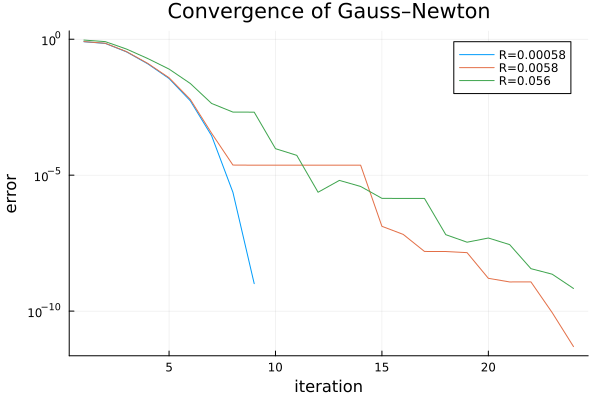

In [8]:
using FNCFunctions, LinearAlgebra, Plots, Printf

plt = plot(xlabel="iteration", yaxis=(:log10, "error"),
    title="Convergence of Gauss–Newton")
for R in [1e-3, 1e-2, 1e-1]
    # Define the perturbed function.
    f(x) = g(x) - g(p) + R * normalize([-1, 1, -1])
    x = FNC.levenberg(f, [0, 0])
    r = x[end]
    err = [norm(x - r) for x in x[1:end-1]]
    normres = norm(f(r))
    plot!(err, label=@sprintf("R=%.2g", normres))
end
plt

## Example 4.7.2

In [9]:
m = 25;
s = range(0.05, 6, length=m)
ŵ = @. 2 * s / (0.5 + s)                      # exactly on the curve
w = @. ŵ + 0.15 * cos(2 * exp(s / 16) * s);     # smooth noise added

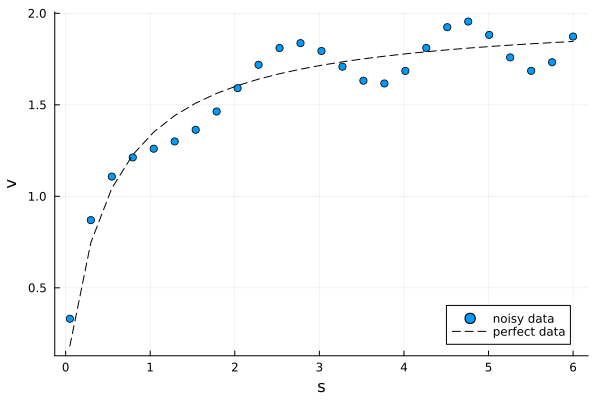

In [10]:
using Plots
scatter(s, w, label="noisy data",
    xlabel="s", ylabel="v", leg=:bottomright)
plot!(s, ŵ, l=:dash, color=:black, label="perfect data")

In [11]:
function misfit(x)
    V, Km = x   # rename components for clarity
    return @. V * s / (Km + s) - w
end

misfit (generic function with 1 method)

In [12]:
function misfitjac(x)
    V, Km = x   # rename components for clarity
    J = zeros(m, 2)
    J[:, 1] = @. s / (Km + s)              # dw/dV
    J[:, 2] = @. -V * s / (Km + s)^2         # dw/d_Km
    return J
end

misfitjac (generic function with 1 method)

In [13]:
using FNCFunctions
x₁ = [1, 0.75]
x = FNC.newtonsys(misfit, misfitjac, x₁)


18-element Vector{Vector{Float64}}:
 [1.0, 0.75]
 [1.9569144827495912, 0.0925370469432526]
 [1.817159681304601, 0.2156677280748475]
 [1.9133853481203573, 0.3751071341778403]
 [1.9586232273465318, 0.45212664188575463]
 [1.967477718516489, 0.46737000327982225]
 [1.9685336137107177, 0.4691108589928947]
 [1.9686408796936041, 0.46928476871518787]
 [1.9686514477259254, 0.4693018691889677]
 [1.9686524854297205, 0.46930354801396534]
 [1.9686525872914797, 0.4693037128056018]
 [1.9686525972899849, 0.46930372898112277]
 [1.968652598271411, 0.46930373056886787]
 [1.968652598367745, 0.4693037307247165]
 [1.968652598377201, 0.46930373074001414]
 [1.968652598378129, 0.4693037307415156]
 [1.9686525983782202, 0.469303730741663]
 [1.968652598378229, 0.4693037307416776]

In [14]:
V, Km = x[end]  # final values

2-element Vector{Float64}:
 1.968652598378229
 0.4693037307416776

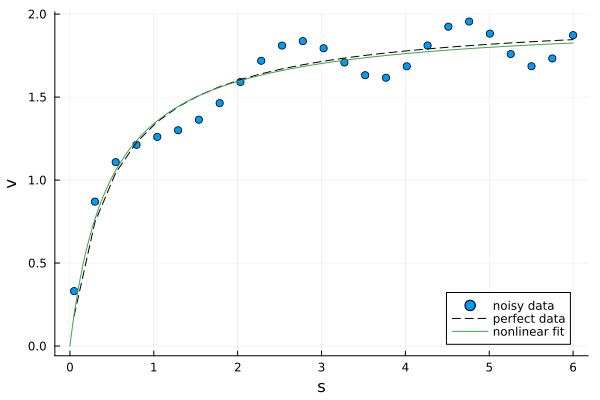

In [15]:
model(s) = V * s / (Km + s)
plot!(model, 0, 6, label="nonlinear fit")

$$
\frac{1}{w} = \frac{\alpha}{s} + \beta = \alpha \cdot s^{-1} + \beta
$$


$$f_i([\alpha,\beta]) = \left(\alpha \cdot \frac{1}{s_i} + \beta\right) - \frac{1}{w_i}$$

In [16]:
A = [s .^ (-1) s .^ 0]
u = 1 ./ w
α, β = A \ u

2-element Vector{Float64}:
 0.1247633370990153
 0.5713959100431232

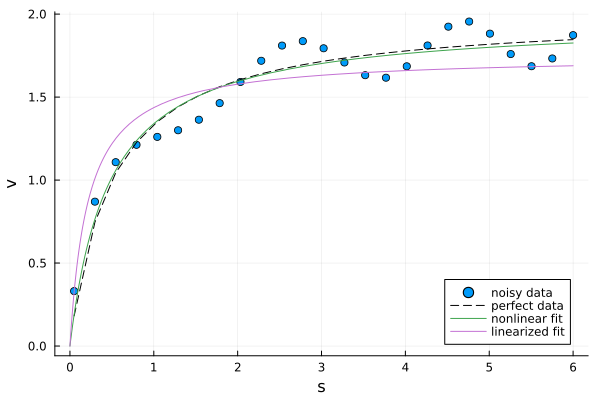

In [17]:
linmodel(x) = 1 / (β + α / x)
plot!(linmodel, 0, 6, label="linearized fit")